In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
## rmk: problem is given with the 1D Fourier Law, variable coefficients,
## and Robin boundary conditions


## input: vector x holding node coordinates
##        function handle a, specified in a separate routine
##        vector kappa specifying boundary conditions k_0, k_L

## output: assembled stiffness matrix

def stiffness1D(x, a, kappa):
    n = len(x) - 1
    A = np.zeros((n+1, n+1)) 
    for i in range(0, n):
        h = x[i+1] - x[i]
        xmid = (x[i+1] + x[i])/2 # interval mid-point
        amid = a(xmid) # value of a(x) at midpoint

        # rmk: here we use midpoint quadrature to compute entries of A 
        A[i][i] = A[i][i] + amid/h
        A[i][i+1] = A[i][i+1] - amid/h
        A[i+1][i] = A[i+1][i] - amid/h
        A[i+1][i+1] = A[i+1][i+1] + amid/h
        
    A[0][0] = A[0][0] + kappa[0]
    A[n][n] = A[n][n] + kappa[1]
    return A
        

In [5]:
## input: vector x holding node coordinates
##        function f, specified in a separate routine 

## output: assembled load vector

def loadAssembler1D(x, f):
    n = len(x) - 1
    b = np.zeros(n+1)
    for i in range(0,n):
        h = x[i+1] - x[i]
        b[i] = b[i] + f(x[i])*h/2
        b[i+1] = b[i+1] + f(x[i+1])*h/2
    return b

## input: vector x holding node coordinates
##        function handle f, specified in a separate routine
##        vector kappa, specifying boundary conditions k_0, k_L
##        vector g, specifying boundary parameters g_0, g_L
def sourceAssembler1D(x,f,kappa,g):
    n = len(x) - 1
    b = loadAssembler1D(x,f)
    b[0] = b[0] + kappa[0]*g[0]
    b[n] = b[n] + kappa[1]*g[1]
    return b

In [55]:
# test case
def conductivity(x):
    a = 0.1*(5-0.6*x) #heat conductivity times area
    return a
    
def source(x):
    f = 0.03*(x-6)**4 # heat source
    return f 

In [57]:
def FEM1Dtest():
    h = 0.1 # mesh size
    start, end = 2, 8 
    x = np.arange(start, end + h/2, h) # mesh
    kappa = np.array([1.0e6,0.0]) # dirichlet T(2) = -1 approx w/ Robin BC
    g = np.array([-1,0])
    A = stiffness1D(x, conductivity, kappa)
    b = sourceAssembler1D(x, source, kappa, g)
    u = np.linalg.solve(A,b)

    plt.plot(x, u)
    plt.xlabel("x")
    plt.ylabel("u")
    plt.title("1D Poisson Solver")
    plt.grid(True)
    plt.show()

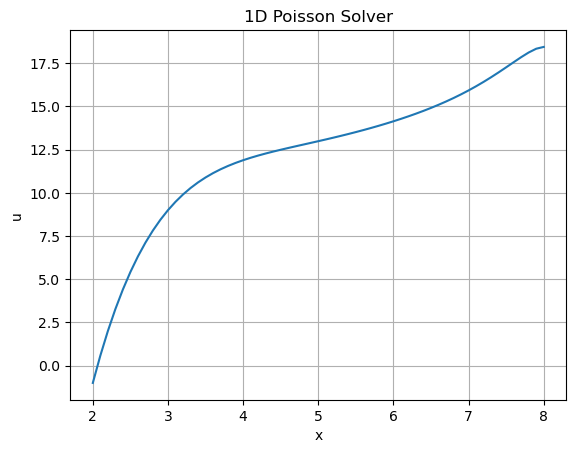

In [59]:
if __name__ == "__main__":
    FEM1Dtest()